
Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   267 non-null    object        
 1   Date                                     267 non-null    datetime64[ns]
 2   Frequency                                267 non-null    object        
 3   Estimated Unemployment Rate (%)          267 non-null    float64       
 4   Estimated Employed                       267 non-null    int64         
 5   Estimated Labour Participation Rate (%)  267 non-null    float64       
 6   Region.1                                 267 non-null    object        
 7   longitude                                267 non-null    float64       
 8   latitude                                 267 non-null    float64       
dtypes: datetime64[ns](1),

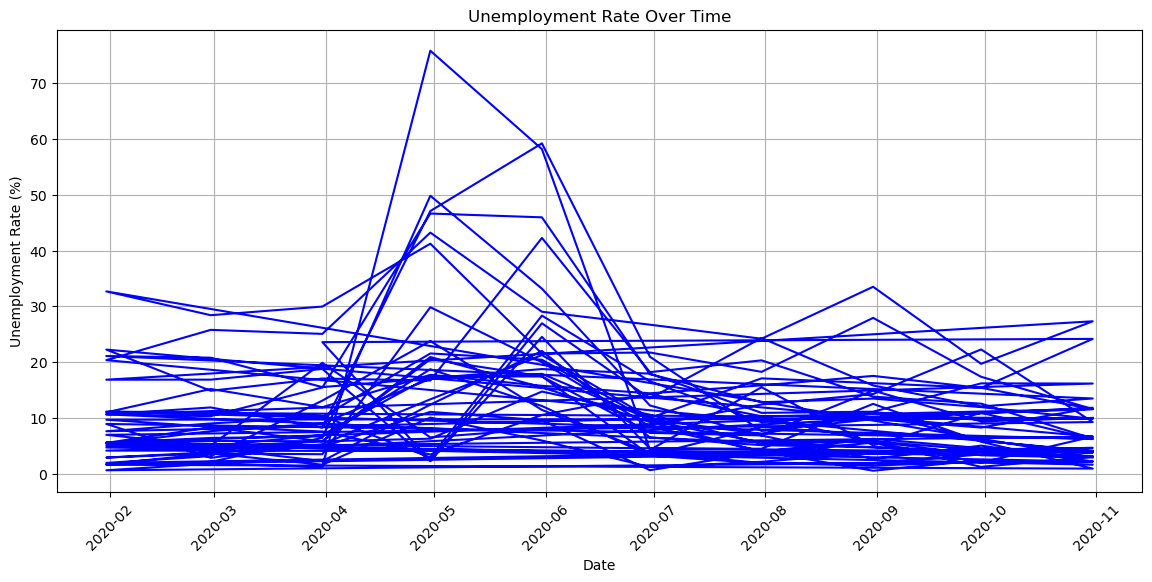

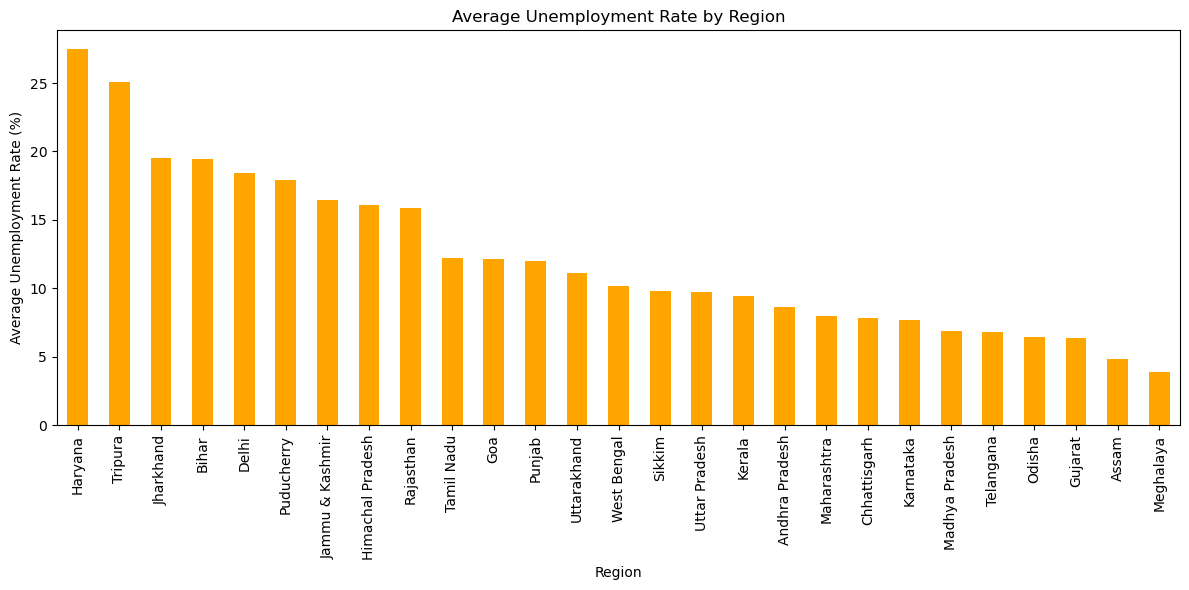

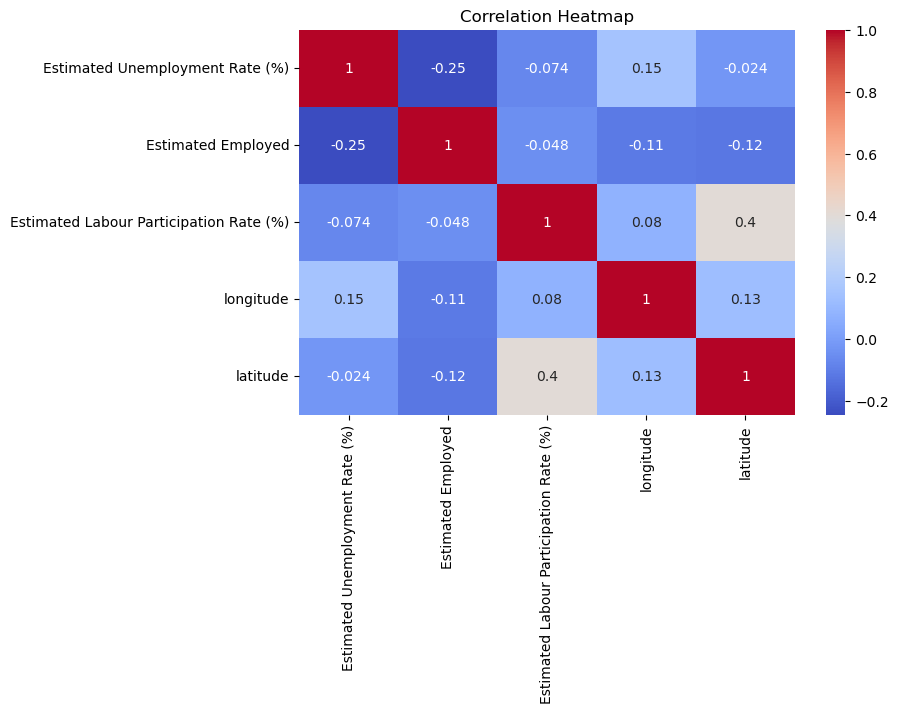


Average Unemployment Before Covid-19: 9.23
Average Unemployment During Covid-19: 12.96


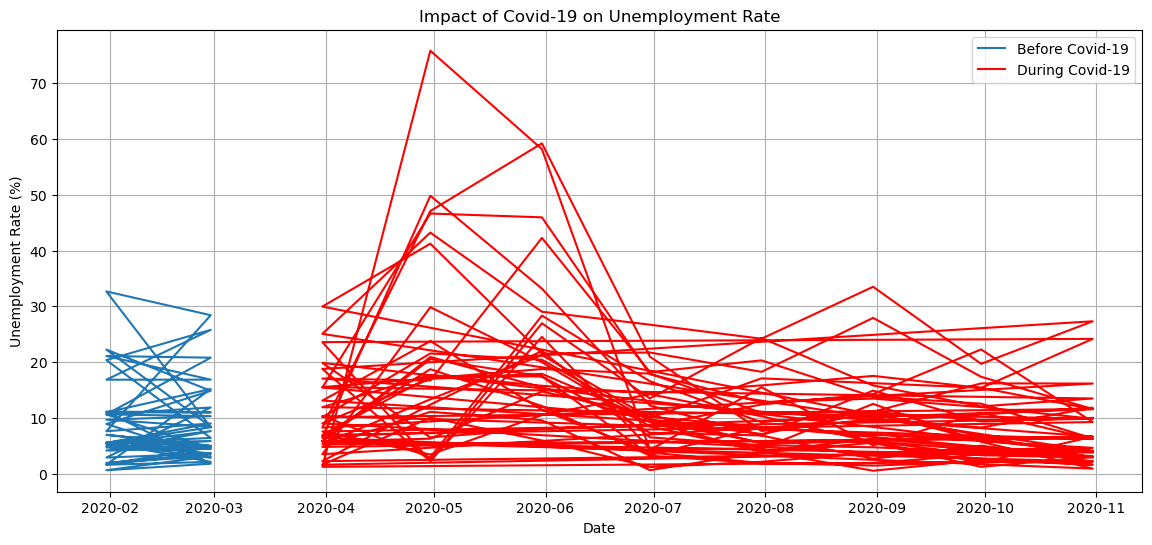

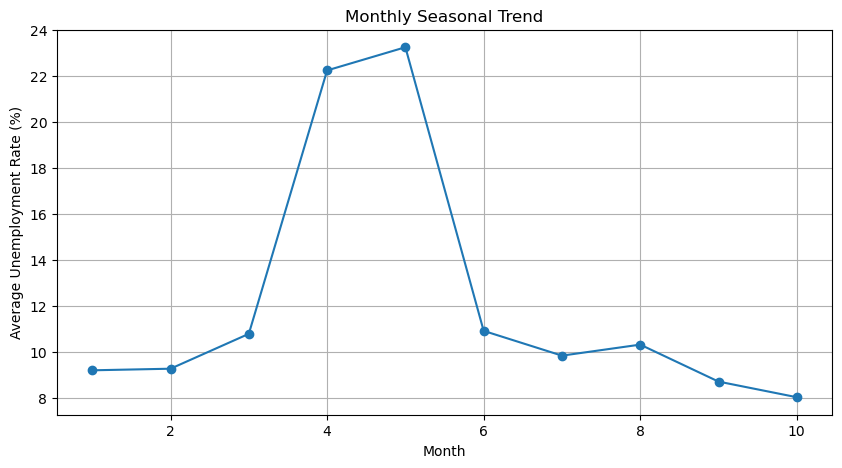


========== KEY INSIGHTS ==========
1. Unemployment rates increased significantly during the Covid-19 pandemic.
2. Certain regions experienced consistently higher unemployment rates.
3. Seasonal trends indicate fluctuations in employment across different months.
4. Economic recovery trends can be observed after lockdown periods.
5. Correlation analysis helps understand relationships between unemployment and labor participation.

========== POLICY RECOMMENDATIONS ==========
1. Governments should strengthen employment support during economic crises.
2. Skill development and digital employment programs can reduce unemployment.
3. High-unemployment regions need targeted economic and industrial policies.
4. Seasonal unemployment can be reduced through rural employment initiatives.
5. Social welfare programs are important for vulnerable workers during pandemics.

Conclusion:
This project analyzed unemployment trends using Python, explored Covid-19 impacts, identified seasonal patterns, and g

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Load datasets
file1 = 'Unemployment in India.csv'
file2 = 'Unemployment_Rate_upto_11_2020.csv'
# Read CSV files
df1 = pd.read_csv(file1)
df2 = pd.read_csv(file2)
# Remove extra spaces from column names
df1.columns = df1.columns.str.strip()
df2.columns = df2.columns.str.strip()
# Convert Date column into datetime format
if 'Date' in df1.columns:
    df1['Date'] = pd.to_datetime(df1['Date'], dayfirst=True, errors='coerce')
if 'Date' in df2.columns:
    df2['Date'] = pd.to_datetime(df2['Date'], dayfirst=True, errors='coerce')
# Remove missing values
df1.dropna(inplace=True)
df2.dropna(inplace=True)
# Remove duplicate rows
df1.drop_duplicates(inplace=True)
df2.drop_duplicates(inplace=True)
print("\nDataset Information:\n")
print(df2.info())
print("\nFirst 5 Rows:\n")
print(df2.head())
print("\nStatistical Summary:\n")
print(df2.describe())
plt.figure(figsize=(14,6))
plt.plot(
    df2['Date'],
    df2['Estimated Unemployment Rate (%)'],
    color='blue'
)
plt.title('Unemployment Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()
region_avg = df2.groupby('Region')['Estimated Unemployment Rate (%)'].mean()
region_avg = region_avg.sort_values(ascending=False)
plt.figure(figsize=(12,6))
region_avg.plot(kind='bar', color='orange')
plt.title('Average Unemployment Rate by Region')
plt.xlabel('Region')
plt.ylabel('Average Unemployment Rate (%)')
plt.tight_layout()
plt.show()
plt.figure(figsize=(8,5))
sns.heatmap(
    df2.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()
pre_covid = df2[df2['Date'] < '2020-03-01']
during_covid = df2[df2['Date'] >= '2020-03-01']
# Calculate average unemployment rates
pre_avg = pre_covid['Estimated Unemployment Rate (%)'].mean()
during_avg = during_covid['Estimated Unemployment Rate (%)'].mean()
print("\nAverage Unemployment Before Covid-19:", round(pre_avg, 2))
print("Average Unemployment During Covid-19:", round(during_avg, 2))
# Plot Covid impact
plt.figure(figsize=(14,6))
plt.plot(
    pre_covid['Date'],
    pre_covid['Estimated Unemployment Rate (%)'],
    label='Before Covid-19'
)
plt.plot(
    during_covid['Date'],
    during_covid['Estimated Unemployment Rate (%)'],
    label='During Covid-19',
    color='red'
)
plt.title('Impact of Covid-19 on Unemployment Rate')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.legend()
plt.grid(True)
plt.show()
# Extract month
if 'Date' in df2.columns:
    df2['Month'] = df2['Date'].dt.month
# Monthly average unemployment
monthly_avg = df2.groupby('Month')['Estimated Unemployment Rate (%)'].mean()
plt.figure(figsize=(10,5))
monthly_avg.plot(marker='o')
plt.title('Monthly Seasonal Trend')
plt.xlabel('Month')
plt.ylabel('Average Unemployment Rate (%)')
plt.grid(True)
plt.show()
print("\n========== KEY INSIGHTS ==========")
print("1. Unemployment rates increased significantly during the Covid-19 pandemic.")
print("2. Certain regions experienced consistently higher unemployment rates.")
print("3. Seasonal trends indicate fluctuations in employment across different months.")
print("4. Economic recovery trends can be observed after lockdown periods.")
print("5. Correlation analysis helps understand relationships between unemployment and labor participation.")
print("\n========== POLICY RECOMMENDATIONS ==========")

print("1. Governments should strengthen employment support during economic crises.")

print("2. Skill development and digital employment programs can reduce unemployment.")

print("3. High-unemployment regions need targeted economic and industrial policies.")

print("4. Seasonal unemployment can be reduced through rural employment initiatives.")

print("5. Social welfare programs are important for vulnerable workers during pandemics.")
print("\nConclusion:")
print(
    "This project analyzed unemployment trends using Python, explored Covid-19 impacts, "
    "identified seasonal patterns, and generated insights useful for economic and social policy planning."
)
